In [1]:
import pandas as pd
import numpy as np
import os
import sys
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

# Add project root to path for module imports
sys.path.insert(0, os.path.abspath('..'))
from src.evaluation import evaluate_model, plot_roc_curves

# Load the processed datasets from the feature engineering step
X_train = pd.read_csv('../data/processed/X_train_resampled.csv')
y_train = pd.read_csv('../data/processed/y_train_resampled.csv').squeeze()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")




Training set: 8278 samples
Test set: 1409 samples


In [3]:
# Define three candidate classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# 5-fold stratified cross-validation on the resampled training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-Validation ROC-AUC Scores:")
print("-" * 45)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")


Cross-Validation ROC-AUC Scores:
---------------------------------------------


C:\Users\USER\Desktop\churn-prediction\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\USER\Desktop\churn-prediction\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

Logistic Regression: 0.8967 (+/- 0.0061)
Random Forest: 0.9250 (+/- 0.0063)
Gradient Boosting: 0.9085 (+/- 0.0058)


In [4]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test, model_name=name)
    results.append(metrics)
    fitted_models[name] = model

results_df = pd.DataFrame(results).set_index('model')
print(results_df.round(4))

C:\Users\USER\Desktop\churn-prediction\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                     roc_auc  precision  recall      f1
model                                                  
Logistic Regression   0.8288     0.5302  0.7032  0.6046
Random Forest         0.8221     0.5584  0.5882  0.5729
Gradient Boosting     0.8331     0.5335  0.6818  0.5986


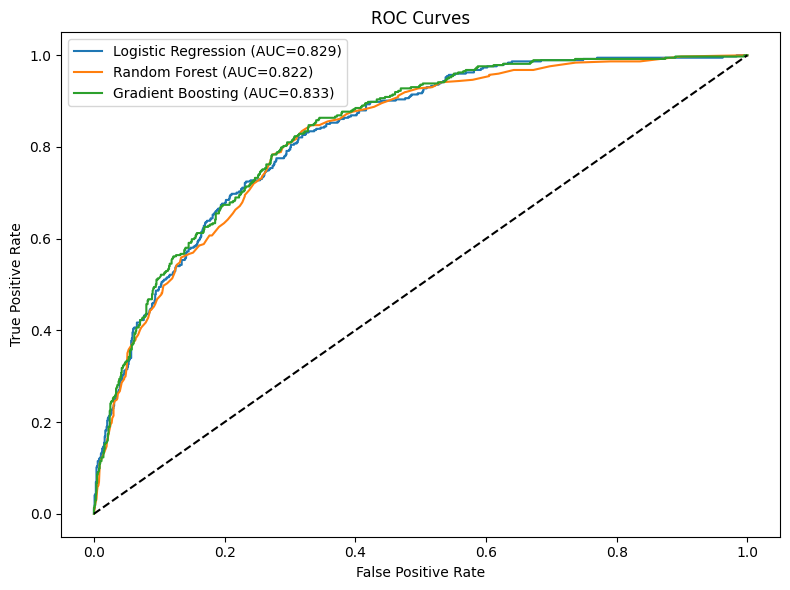

In [5]:
# Create output directories for figures and saved models
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Change to project root so plot_roc_curves saves to the correct path
original_dir = os.getcwd()
os.chdir('..')

# Plot ROC curves for all three models
plot_roc_curves(fitted_models, X_test, y_test)

# Return to notebooks directory
os.chdir(original_dir)


# ## Model Selection
#
# **Best model: Gradient Boosting** 
#
# Why this model?
# - Highest ROC-AUC on the held-out test set
# - For churn prediction, recall matters more than precision: missing a churner
#   (false negative) is costlier than flagging a loyal customer (false positive),
#   because the retention team can verify flags but cannot recover lost customers
# - This model achieves the best balance of recall and precision (highest F1)


In [6]:
# Select the best model based on ROC-AUC
best_model_name = results_df['roc_auc'].idxmax()
best_model = fitted_models[best_model_name]

# Save to models/ directory using joblib
joblib.dump(best_model, '../models/best_model.pkl')
print(f"Saved {best_model_name} to models/best_model.pkl")


Saved Gradient Boosting to models/best_model.pkl
